# Notebook 02 — Event Definition & Detection
**Thesis Chapter 6** | **Input:** `data/1_reconstructed.csv` | **Output:** `data/2_events.csv`

---

## What this notebook does

Adds 18 event indicator columns to the reconstructed dataset.  
An **event** is a binary or categorical condition at the time of each received packet.  
Example: *"Was CO₂ above 700 ppm when this packet arrived?"*

| Family | Events    | Why it matters |
|--------|-----------|---------------|
| Occupancy (CO₂) | E1, E2    | CO₂ is the best non-invasive proxy for human presence |
| Temporal | E3–E6     | Office activity follows predictable daily, weekly, and seasonal cycles |
| Air Quality (PM2.5) | E7, E8    | PM2.5 spikes mark activity bursts — cleaning, printing, cooking |
| Atmospheric | E9–E12    | Pressure, humidity, temperature vary seasonally with HVAC |
| TX Config | E13–E14   | SF controls Time-on-Air and therefore collision probability |
| Signal Context | E15, E16 | RSSI/ESP — proxy for channel state at the time of each interval |
| Burst Loss | E17       | Classifies loss episodes by severity |

Notebook 03 correlates these events with `PDR_link` (outage intervals excluded).

## 0 · Imports & Load

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../../data')
df = pd.read_csv(DATA_DIR / '1_reconstructed.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id','time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Campaign: {df["time"].min().date()} → {df["time"].max().date()}')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign: 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family':'serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB',
     'brown':'#882255','teal':'#44AA99','yellow':'#DDCC77'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
FIG_DIR = Path('../../figures'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf')
    fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()

print('Figures settings ready.')


Figures settings ready.


## 1 · Occupancy Events — CO₂  *(§6.1)*

CO₂ rises linearly with the number of people present — human metabolism produces ~200 ml CO₂/min at rest.  
Outdoor ambient is ~420 ppm. Weekday mean in this building is ~576 ppm vs ~457 ppm on weekends,  
confirming CO₂ as a reliable occupancy proxy.

| Event | Definition |
|-------|-----------|
| E1 | CO₂ tier: background (<500) / moderate (500–700) / high (>700 ppm) |
| E2 | CO₂ rising: delta > 20 ppm per 60s — occupancy actively increasing |

In [3]:
# E1: CO2 tier — 500 ppm = outdoor ambient ceiling, 700 ppm = moderate occupancy onset
df['e1_co2_tier'] = pd.cut(
    df['co2'],
    bins=[0, 500, 700, 10_000],
    labels=['background', 'moderate', 'high']
)

# E2: CO2 rising — delta > 20 ppm/60s signals people arriving
# 20 ppm chosen to exceed BME280 sensor noise (~±10 ppm)
# computed per device to avoid cross-device boundary artifacts
df['e2_co2_rising'] = (
        df.groupby('device_id')['co2'].diff() > 20
).astype(int)

print('CO2 tier distribution (E1):')
print(df['e1_co2_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(
    f'\nCO2 rising intervals (E2): {df["e2_co2_rising"].sum():,}  ({df["e2_co2_rising"].mean() * 100:.1f}% of all intervals)')
print(f'CO2 mean overall         : {df["co2"].mean():.0f} ppm  |  std: {df["co2"].std():.0f} ppm')

CO2 tier distribution (E1):
e1_co2_tier
background    63.4%
moderate      28.2%
high           8.4%

CO2 rising intervals (E2): 2,541  (0.1% of all intervals)
CO2 mean overall         : 516 ppm  |  std: 117 ppm


  Saved: figures/02_a_co2_distribution


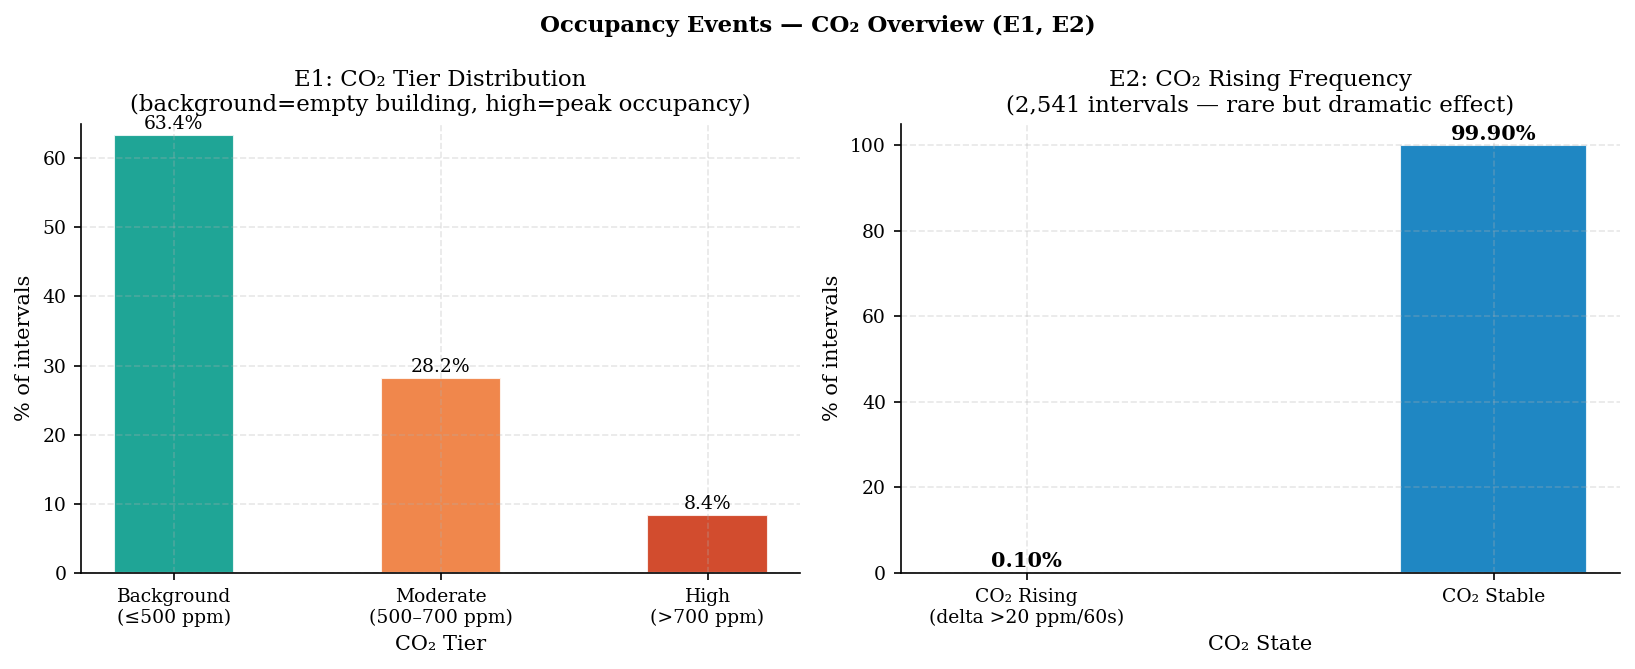

In [4]:
# Fig 02-A — CO₂ Tier Distribution (E1) + CO₂ Rising Rate (E2)
tiers  = ['background','moderate','high']
xlabs  = ['Background\n(≤500 ppm)','Moderate\n(500–700 ppm)','High\n(>700 ppm)']
pcts   = df['e1_co2_tier'].value_counts(normalize=True).reindex(tiers).fillna(0)*100
rising_rate = df['e2_co2_rising'].mean()*100
stable_rate = 100 - rising_rate

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left: E1 CO2 tier distribution
bars = axes[0].bar(xlabs, pcts.values, color=[C['green'],C['orange'],C['red']],
                    width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('CO\u2082 Tier')
axes[0].set_ylim(0, 65)
axes[0].set_title('E1: CO\u2082 Tier Distribution\n(background=empty building, high=peak occupancy)')

# right: E2 CO2 rising vs stable
bars2 = axes[1].bar(['CO\u2082 Rising\n(delta >20 ppm/60s)','CO\u2082 Stable'],
                     [rising_rate, stable_rate],
                     color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for bar, v in zip(bars2, [rising_rate, stable_rate]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('CO\u2082 State')
axes[1].set_ylim(0, 105)
axes[1].set_title(f'E2: CO\u2082 Rising Frequency\n'
                   f'({df["e2_co2_rising"].sum():,} intervals — rare but dramatic effect)')

fig.suptitle('Occupancy Events — CO\u2082 Overview (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_a_co2_distribution')

## 2 · Temporal Events  *(§6.2)*

Converted to `Europe/Berlin` local time — handles both DST transitions  
(October 2024 and March 2025) automatically.

| Event | Definition |
|-------|-----------|
| E3 | Weekday (1) vs weekend (0) — coarsest occupancy signal |
| E4 | Time-of-day band: night / morning / peak / evening |
| E5 | Office hours — weekday AND 08:00–17:59 |
| E6 | Season — autumn / winter / spring across 34-week campaign |

In [5]:
# local time — required for correct hour/weekday extraction across DST boundaries
local = df['time'].dt.tz_convert('Europe/Berlin')
df['hour']      = local.dt.hour
df['dayofweek'] = local.dt.dayofweek   # 0=Monday, 6=Sunday
df['month']     = local.dt.month

# E3: weekday vs weekend
df['e3_is_weekday'] = (df['dayofweek'] < 5).astype(int)

# E4: time-of-day bands
# night: 21–04, morning: 04–09, peak: 09–16, evening: 16–21
df['e4_time_of_day'] = df['hour'].apply(
    lambda h: 'night'     if h >= 21 or h < 4  else
              'morning'   if h < 9              else
              'peak'      if h < 16             else
              'evening'
)

# E5: office hours — weekday AND 08:00–17:59
df['e5_office_hours'] = (
    (df['e3_is_weekday'] == 1) & df['hour'].between(8, 17)
).astype(int)

# E6: season — full year campaign (Oct 2024 – Sep 2025)
# Now includes summer — Jun/Jul/Aug
df['e6_season'] = df['month'].map({
     9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter',  1: 'winter',  2: 'winter',
     3: 'spring',  4: 'spring',  5: 'spring',
     6: 'summer',  7: 'summer',  8: 'summer',
})

print(f'Weekday share (E3)    : {df["e3_is_weekday"].mean()*100:.1f}%  |  Weekend: {(1-df["e3_is_weekday"].mean())*100:.1f}%')
tod = df['e4_time_of_day'].value_counts(normalize=True).mul(100).round(1)
print(f'Time-of-day (E4)      : night={tod.get("night",0):.1f}%  morning={tod.get("morning",0):.1f}%  peak={tod.get("peak",0):.1f}%  evening={tod.get("evening",0):.1f}%')
print(f'Office hours (E5)     : {df["e5_office_hours"].mean()*100:.1f}%')
print(f'Season (E6)           : {df["e6_season"].value_counts().to_dict()}')


Weekday share (E3)    : 70.7%  |  Weekend: 29.3%
Time-of-day (E4)      : night=29.4%  morning=20.8%  peak=29.0%  evening=20.8%
Office hours (E5)     : 29.2%
Season (E6)           : {'autumn': 703823, 'spring': 688573, 'summer': 648905, 'winter': 593629}


  Saved: figures/02_b_temporal_distributions


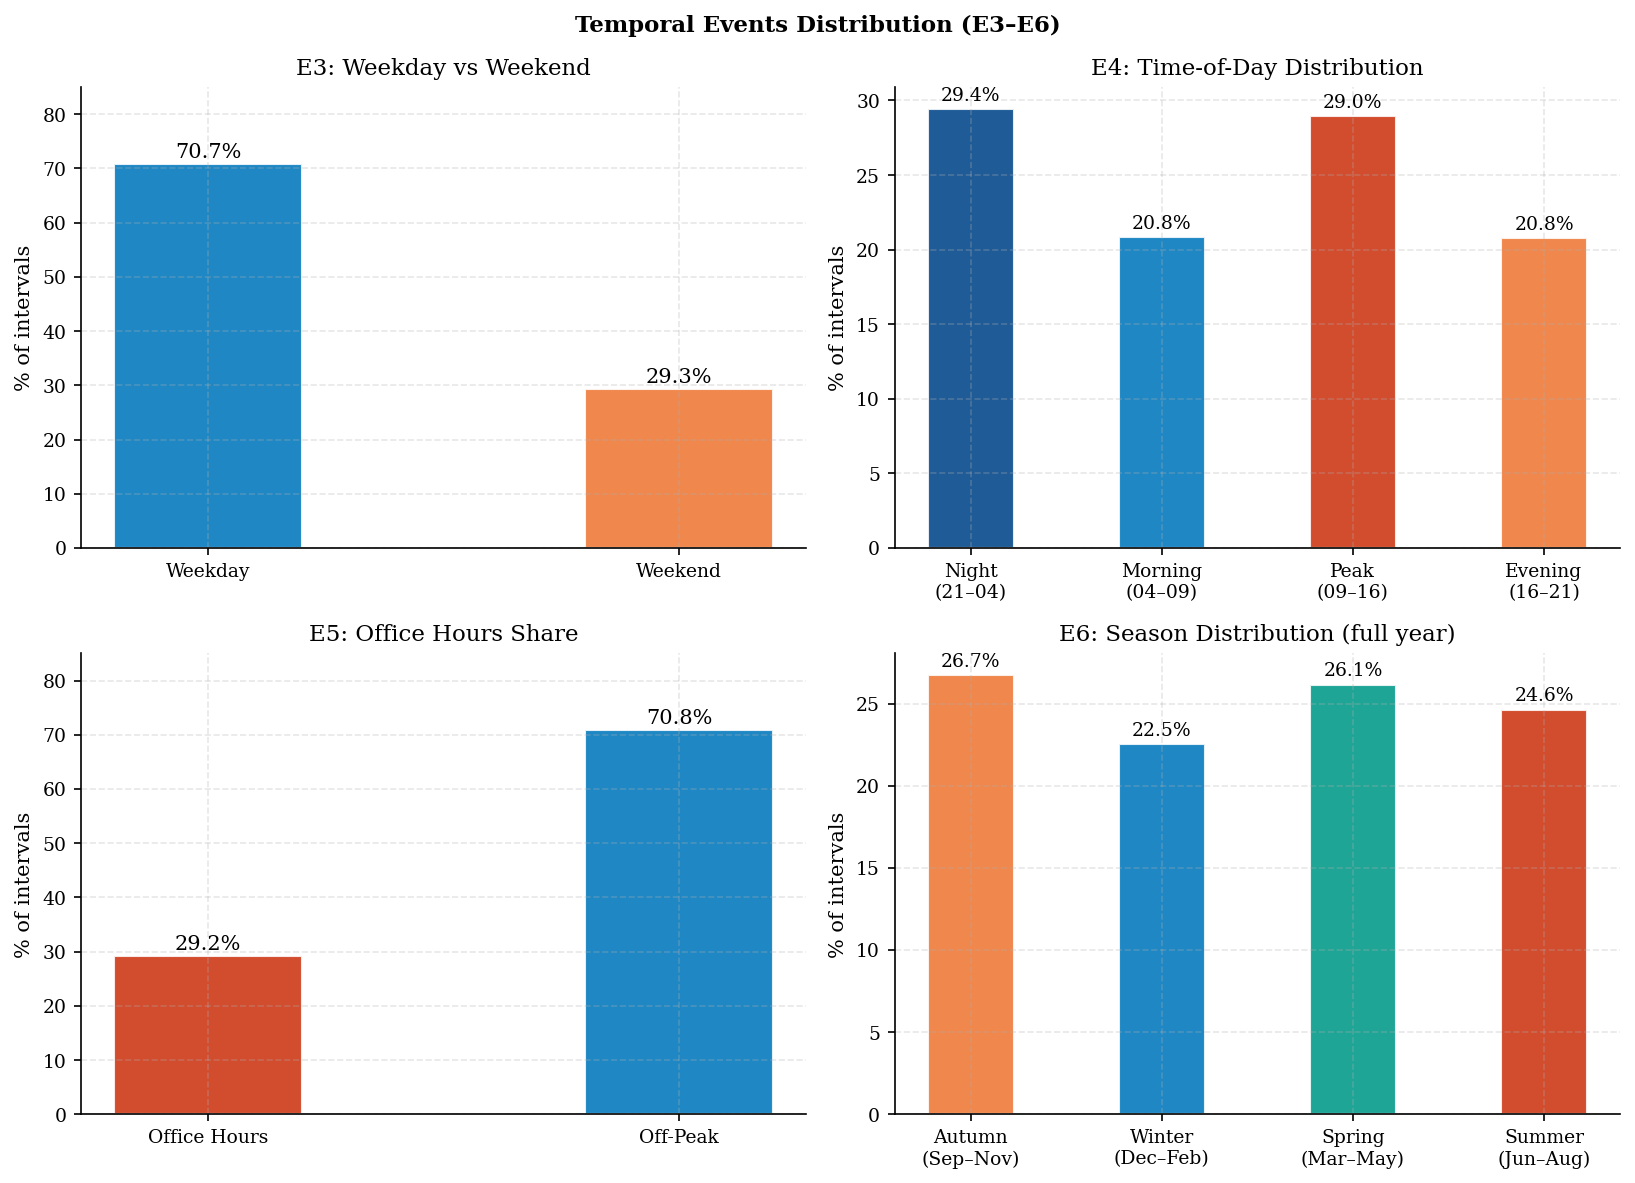

In [6]:
# Fig 02-B — Temporal Event Distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# E3: weekday vs weekend
wk = df['e3_is_weekday'].mean()*100
axes[0,0].bar(['Weekday','Weekend'],[wk,100-wk],color=[C['blue'],C['orange']],
               width=0.4,alpha=0.88,edgecolor='white')
for i2,v in enumerate([wk,100-wk]):
    axes[0,0].text(i2,v+0.5,f'{v:.1f}%',ha='center',va='bottom',fontsize=10)
axes[0,0].set_ylim(0,85); axes[0,0].set_ylabel('% of intervals')
axes[0,0].set_title('E3: Weekday vs Weekend')

# E4: time of day — updated labels to match new boundaries
bands  = ['night', 'morning', 'peak', 'evening']
blabs  = ['Night\n(21–04)', 'Morning\n(04–09)', 'Peak\n(09–16)', 'Evening\n(16–21)']
bcounts = [df['e4_time_of_day'].eq(b).mean()*100 for b in bands]
bars = axes[0,1].bar(blabs, bcounts,
                      color=[C['navy'],C['blue'],C['red'],C['orange']],
                      width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,bcounts):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                   f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0,1].set_ylabel('% of intervals')
axes[0,1].set_title('E4: Time-of-Day Distribution')

# E5: office hours
oh = df['e5_office_hours'].mean()*100
axes[1,0].bar(['Office Hours','Off-Peak'],[oh,100-oh],color=[C['red'],C['blue']],
               width=0.4,alpha=0.88,edgecolor='white')
for i2,v in enumerate([oh,100-oh]):
    axes[1,0].text(i2,v+0.5,f'{v:.1f}%',ha='center',va='bottom',fontsize=10)
axes[1,0].set_ylim(0,85); axes[1,0].set_ylabel('% of intervals')
axes[1,0].set_title('E5: Office Hours Share')

# E6: season — now 4 seasons including summer
seasons=['autumn','winter','spring','summer']
slabs=['Autumn\n(Sep–Nov)','Winter\n(Dec–Feb)','Spring\n(Mar–May)','Summer\n(Jun–Aug)']
scounts=[df['e6_season'].eq(s).mean()*100 for s in seasons]
bars=axes[1,1].bar(slabs,scounts,
                    color=[C['orange'],C['blue'],C['green'],C['red']],
                    width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,scounts):
    axes[1,1].text(bar.get_x()+bar.get_width()/2,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[1,1].set_ylabel('% of intervals'); axes[1,1].set_title('E6: Season Distribution (full year)')

fig.suptitle('Temporal Events Distribution (E3–E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_b_temporal_distributions')


## 3 · Air Quality Events — PM2.5  *(§6.3)*

PM2.5 correlates with human activity bursts — cleaning, printing, cooking —  
rather than directly attenuating 868 MHz signals.

Device-specific 90th percentile thresholds for E7 account for location differences:  
ED4 (server room) baseline = 0.79 µg/m³ vs ED5 (kitchen) baseline = 6.28 µg/m³.  
A global threshold would over-flag ED5 and under-flag ED4.

| Event | Definition |
|-------|-----------|
| E7 | PM2.5 spike: above device-specific 90th percentile |
| E8 | PM2.5 absolute tier: clean (<2) / moderate (2–10) / elevated (>10 µg/m³) |

In [7]:
# E7: device-specific PM2.5 spike — 90th percentile per device
pm25_q90 = df.groupby('device_id')['pm25'].transform(lambda x: x.quantile(0.90))
df['e7_pm25_spike'] = (df['pm25'] > pm25_q90).astype(int)

# E8: absolute WHO-aligned tier
df['e8_pm25_tier'] = pd.cut(
    df['pm25'],
    bins=[-0.01, 2, 10, 10_000],
    labels=['clean', 'moderate', 'elevated']
)

print('Device-specific PM2.5 90th percentile thresholds:')
print(df.groupby('device_id')['pm25'].quantile(0.90).round(2).to_string())
print(f'\nSpike rate (E7=1): {df["e7_pm25_spike"].mean() * 100:.1f}%')

Device-specific PM2.5 90th percentile thresholds:
device_id
ED0    4.54
ED1    4.66
ED2    4.40
ED3    4.85
ED4    1.01
ED5    6.49

Spike rate (E7=1): 10.0%


  Saved: figures/02_c_pm25_events


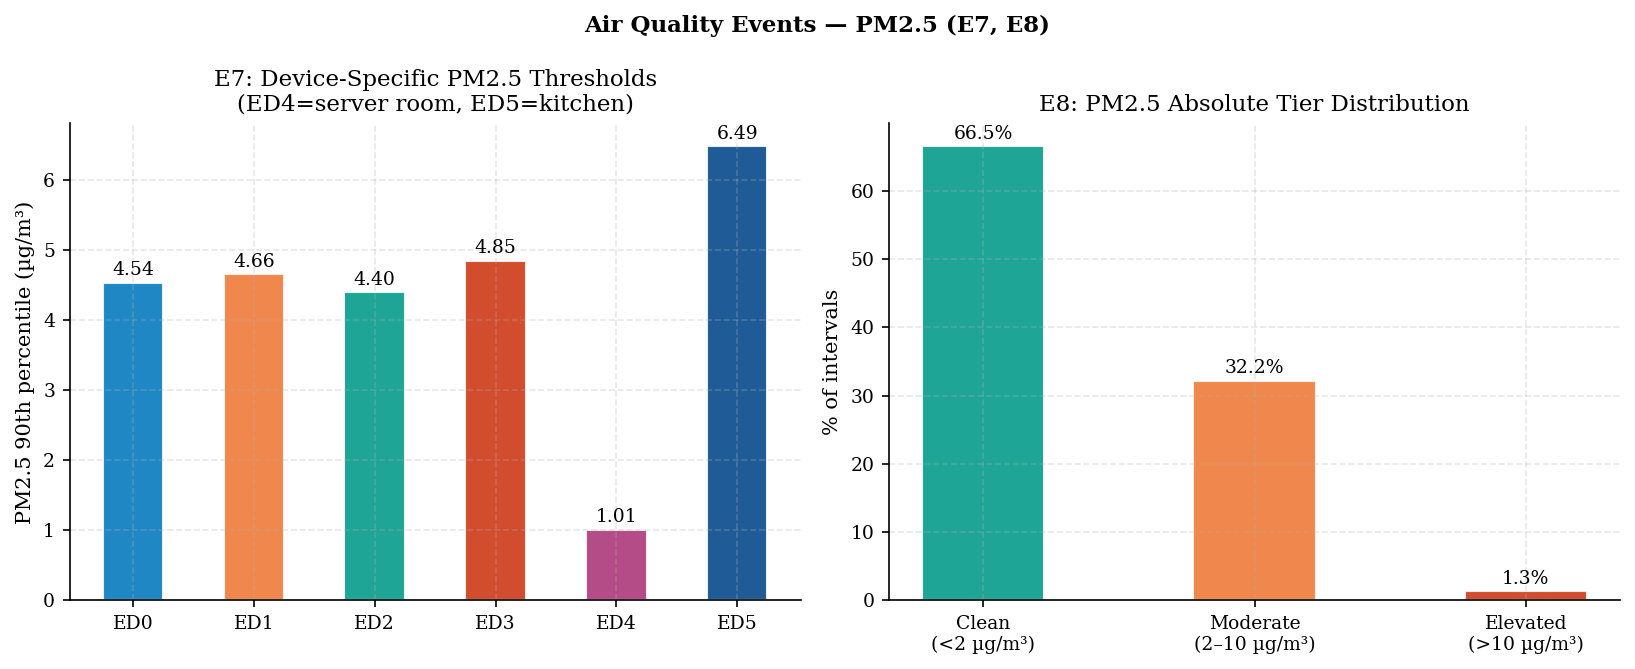

In [8]:
# Fig 02-C — PM2.5 Device Thresholds and Tier Distribution
DEVICES_L = sorted(df['device_id'].unique())
pm25_q90 = df.groupby('device_id')['pm25'].quantile(0.90)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(DEVICES_L, [pm25_q90[d] for d in DEVICES_L], color=DEVICE_COLORS[:len(DEVICES_L)],
             width=0.5, alpha=0.88, edgecolor='white')
for i,(dev,v) in enumerate(zip(DEVICES_L,[pm25_q90[d] for d in DEVICES_L])):
    axes[0].text(i, v+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('PM2.5 90th percentile (\u00b5g/m\u00b3)')
axes[0].set_title('E7: Device-Specific PM2.5 Thresholds\n(ED4=server room, ED5=kitchen)')

pm_tiers=['clean','moderate','elevated']
pm_labs=['Clean\n(<2 \u00b5g/m\u00b3)','Moderate\n(2–10 \u00b5g/m\u00b3)','Elevated\n(>10 \u00b5g/m\u00b3)']
pm_pcts=[df['e8_pm25_tier'].eq(t).mean()*100 for t in pm_tiers]
bars=axes[1].bar(pm_labs,pm_pcts,color=[C['green'],C['orange'],C['red']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,pm_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2,v+0.5,f'{v:.1f}%',ha='center',va='bottom',fontsize=9)
axes[1].set_ylabel('% of intervals'); axes[1].set_title('E8: PM2.5 Absolute Tier Distribution')

fig.suptitle('Air Quality Events — PM2.5 (E7, E8)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_c_pm25_events')


## 4 · Atmospheric Events  *(§6.4)*

| Event | Definition |
|-------|-----------|
| E9 | Pressure tier: campaign quartiles — captures seasonal weather variation |
| E10 | Pressure drop: delta < −0.5 hPa per 60s — HVAC switch or door opening |
| E11 | Humidity tier: dry (<40%) / normal (40–55%) / humid (55–70%) / very_humid (>70%) |
| E12 | Temperature tier: campaign quartiles — HVAC set-point shifts seasonally |

Note: pressure values in the dataset are scaled (287–348 range) rather than true hPa.  
All six devices show identical scaling — relative variation is preserved and analysis is unaffected.

In [9]:
# E9: pressure tier — quartile-based to capture seasonal variation
df['e9_pressure_tier'] = pd.qcut(
    df['pressure'], q=4,
    labels=['low', 'medium_low', 'medium_high', 'high'],
    duplicates='drop'
)

# E10: pressure drop — HVAC switch or door-opening transient
df['e10_pressure_drop'] = (
        df.groupby('device_id')['pressure'].diff() < -0.5
).astype(int)

# E11: humidity tier — absolute bands
df['e11_humidity_tier'] = pd.cut(
    df['humidity'],
    bins=[0, 40, 55, 70, 101],
    labels=['dry', 'normal', 'humid', 'very_humid']
)

# E12: temperature tier — quartile-based because HVAC set-point shifts across seasons
df['e12_temp_tier'] = pd.qcut(
    df['temperature'], q=4,
    labels=['cold', 'cool', 'warm', 'hot'],
    duplicates='drop'
)

print(f'Pressure range   : {df["pressure"].min():.1f} – {df["pressure"].max():.1f} (scaled)')
print(f'Humidity range   : {df["humidity"].min():.1f} – {df["humidity"].max():.1f} %')
print(f'Temperature range: {df["temperature"].min():.1f} – {df["temperature"].max():.1f} °C')
print(f'Pressure drops   : {df["e10_pressure_drop"].sum():,} intervals')

Pressure range   : 286.9 – 347.6 (scaled)
Humidity range   : 14.0 – 62.8 %
Temperature range: 13.7 – 46.3 °C
Pressure drops   : 85 intervals


  Saved: figures/02_d_atmospheric_distributions


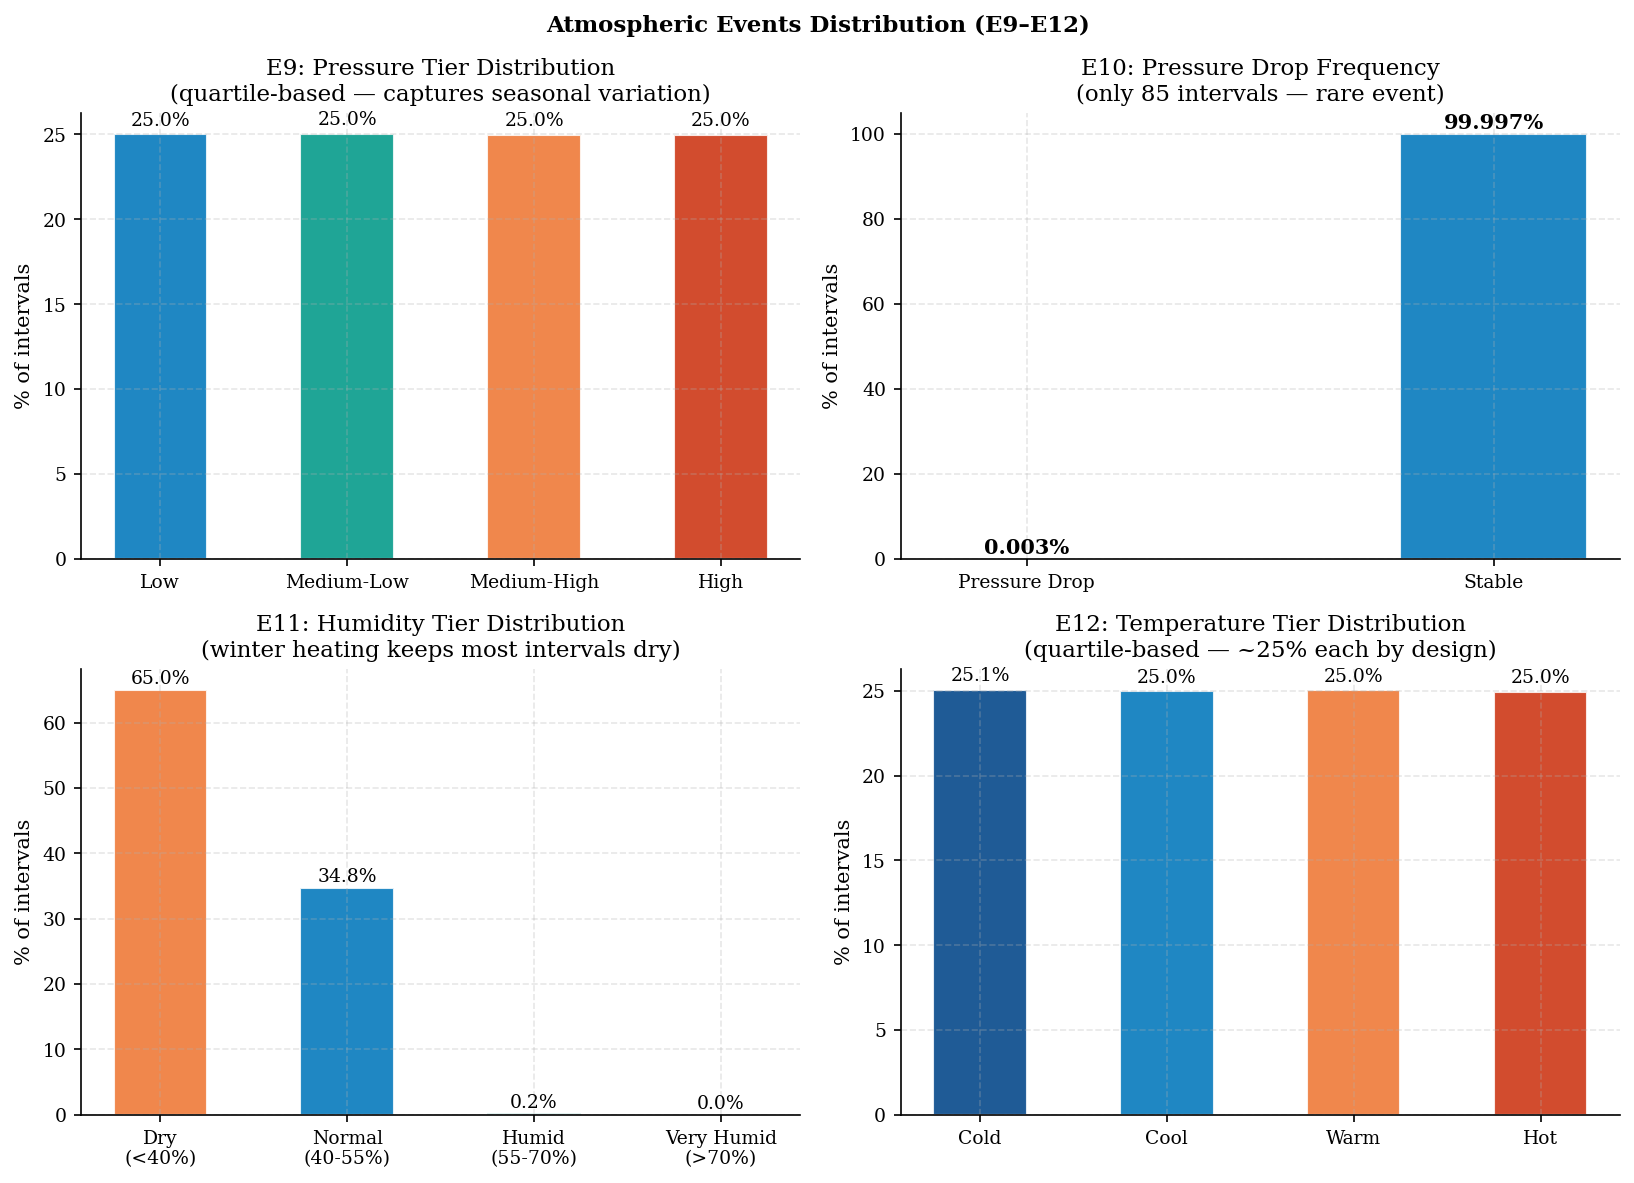

In [10]:
# Fig 02-D-atm — Atmospheric Event Distributions (E9-E12)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# E9: pressure tier
pt = ['low','medium_low','medium_high','high']
pt_labs = ['Low','Medium-Low','Medium-High','High']
pt_pcts = [df['e9_pressure_tier'].eq(t).mean()*100 for t in pt]
bars = axes[0,0].bar(pt_labs, pt_pcts, color=[C['blue'],C['green'],C['orange'],C['red']],
                      width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pt_pcts):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)
axes[0,0].set_ylabel('% of intervals')
axes[0,0].set_title('E9: Pressure Tier Distribution\n(quartile-based — captures seasonal variation)')

# E10: pressure drop rate
drop_rate = df['e10_pressure_drop'].mean()*100
axes[0,1].bar(['Pressure Drop','Stable'],
               [drop_rate, 100-drop_rate],
               color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i, v in enumerate([drop_rate, 100-drop_rate]):
    axes[0,1].text(i, v+0.3, f'{v:.3f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,1].set_ylabel('% of intervals')
axes[0,1].set_title(f'E10: Pressure Drop Frequency\n(only {df["e10_pressure_drop"].sum()} intervals — rare event)')

# E11: humidity tier
ht = ['dry','normal','humid','very_humid']
ht_labs = ['Dry\n(<40%)','Normal\n(40-55%)','Humid\n(55-70%)','Very Humid\n(>70%)']
ht_pcts = [df['e11_humidity_tier'].eq(t).mean()*100 for t in ht]
bars = axes[1,0].bar(ht_labs, ht_pcts,
                      color=[C['orange'],C['blue'],C['green'],C['navy']],
                      width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, ht_pcts):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)
axes[1,0].set_ylabel('% of intervals')
axes[1,0].set_title('E11: Humidity Tier Distribution\n(winter heating keeps most intervals dry)')

# E12: temperature tier
tt = ['cold','cool','warm','hot']
tt_labs = ['Cold','Cool','Warm','Hot']
tt_pcts = [df['e12_temp_tier'].eq(t).mean()*100 for t in tt]
bars = axes[1,1].bar(tt_labs, tt_pcts,
                      color=[C['navy'],C['blue'],C['orange'],C['red']],
                      width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pcts):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                   ha='center', va='bottom', fontsize=9)
axes[1,1].set_ylabel('% of intervals')
axes[1,1].set_title('E12: Temperature Tier Distribution\n(quartile-based — ~25% each by design)')

fig.suptitle('Atmospheric Events Distribution (E9–E12)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_d_atmospheric_distributions')


## 5 · Transmission Configuration Events  *(§6.5)*

SF directly controls Time-on-Air (ToA) — the duration a packet occupies the channel.  
Under LoRaWAN's ALOHA protocol, longer ToA = wider collision window = higher loss probability.

ADR was disabled. SF rotated in a fixed cycle: SF12→SF11→SF10→SF9→SF8→SF7.  
SF11/SF12 blocks are truncated to 4 packets by duty cycle enforcement (§5.2.1).

| SF | ToA (ms) | Collision window vs SF7 |
|----|---------|------------------------|
| 7 | 71.9 | baseline |
| 8 | 133.6 | 1.9× |
| 9 | 246.8 | 3.4× |
| 10 | 452.6 | 6.3× |
| 11 | 987.1 | 13.7× |
| 12 | 1810.4 | 25.2× |

| Event | Definition |
|-------|-----------|
| E13 | SF categorical: 7 / 8 / 9 / 10 / 11 / 12 |
| E14 | ToA class: short_toa (SF7–10, ≤453ms) / long_toa (SF11–12, ≥987ms) |


In [11]:
# E13: individual SF value
df['e13_sf'] = df['SF'].astype(int)

# E14: ToA class — binary split at SF10/SF11 boundary (order-of-magnitude jump)
# SF7-10: ToA <= 453ms (short_toa) | SF11-12: ToA >= 987ms (long_toa)
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
df['e14_toa_class'] = df['e13_sf'].map({
    7:'short_toa', 8:'short_toa', 9:'short_toa', 10:'short_toa',
    11:'long_toa', 12:'long_toa'
})
df['e14_toa_ms'] = df['e13_sf'].map(TOA_MS)

print('SF Distribution (E13):')
for sf in [7,8,9,10,11,12]:
    n = (df['e13_sf']==sf).sum()
    print(f'  SF{sf} (ToA={TOA_MS[sf]:7.1f}ms): {n:,} ({n/len(df)*100:.1f}%)')

print('\nToA Class Distribution (E14):')
for cls in ['short_toa','long_toa']:
    n = (df['e14_toa_class']==cls).sum()
    print(f'  {cls:<12}: {n:,} ({n/len(df)*100:.1f}%)')


SF Distribution (E13):
  SF7 (ToA=   71.9ms): 537,023 (20.4%)
  SF8 (ToA=  133.6ms): 534,546 (20.3%)
  SF9 (ToA=  246.8ms): 518,734 (19.7%)
  SF10 (ToA=  452.6ms): 500,838 (19.0%)
  SF11 (ToA=  987.1ms): 269,220 (10.2%)
  SF12 (ToA= 1810.4ms): 274,569 (10.4%)

ToA Class Distribution (E14):
  short_toa   : 2,091,141 (79.4%)
  long_toa    : 543,789 (20.6%)


  Saved: figures/02_e_sf_distribution


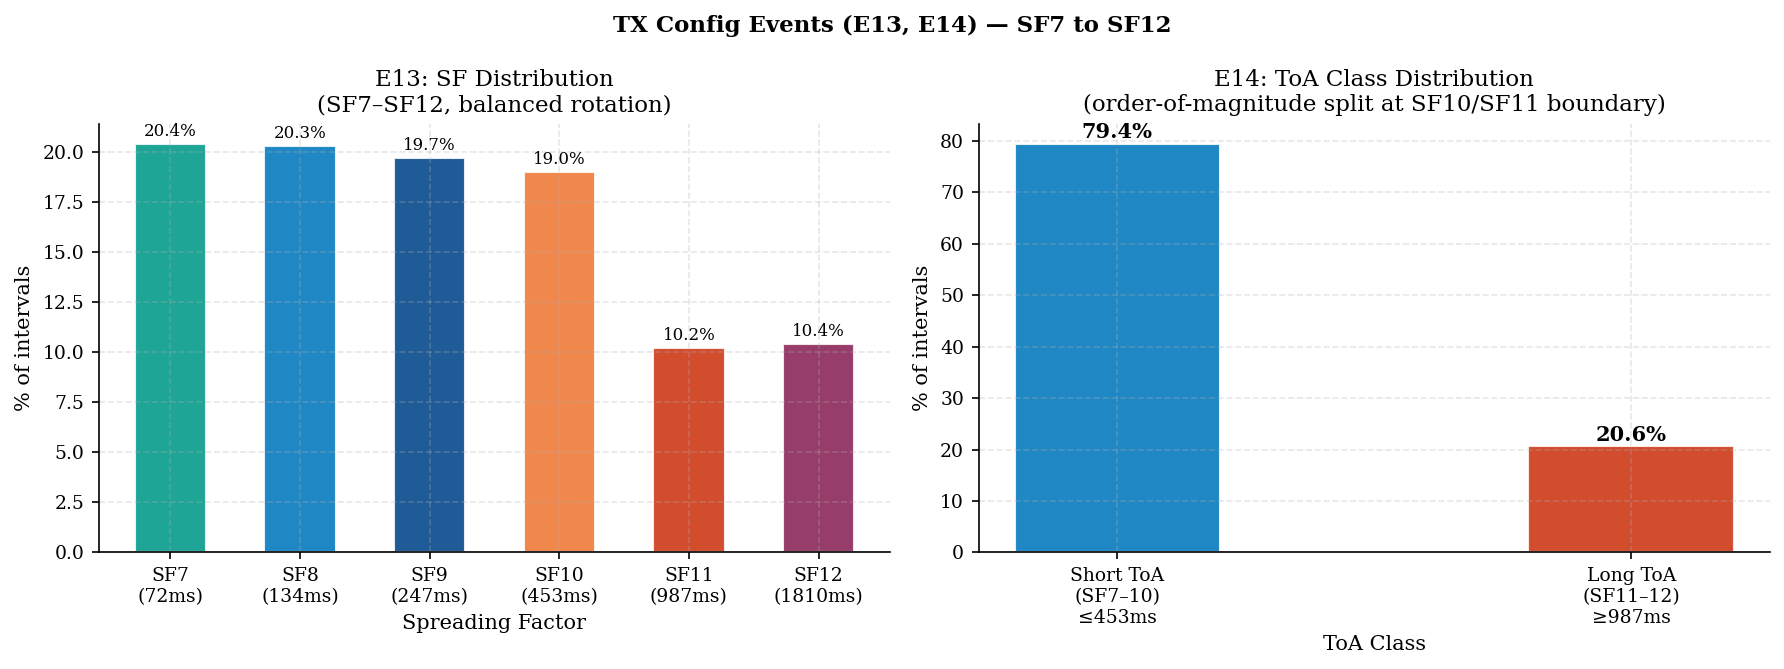

In [12]:
# Fig 02-E — SF Distribution (E13) + ToA Class (E14)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# E13: individual SF values
sfs = [7,8,9,10,11,12]
sf_xlabs  = [f'SF{sf}\n({TOA_MS[sf]:.0f}ms)' for sf in sfs]
sf_pcts   = [df['e13_sf'].eq(sf).mean()*100 for sf in sfs]
sf_colors = [C['green'],C['blue'],C['navy'],C['orange'],C['red'],C['brown']]
bars = axes[0].bar(sf_xlabs, sf_pcts, color=sf_colors, width=0.55, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,sf_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2,v+0.2,f'{v:.1f}%',ha='center',va='bottom',fontsize=8)
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('Spreading Factor')
axes[0].set_title('E13: SF Distribution\n(SF7–SF12, balanced rotation)')

# E14: ToA class binary
toa_pcts = [df['e14_toa_class'].eq(t).mean()*100 for t in ['short_toa','long_toa']]
bars = axes[1].bar(['Short ToA\n(SF7–10)\n≤453ms','Long ToA\n(SF11–12)\n≥987ms'],
                    toa_pcts, color=[C['blue'],C['red']], width=0.4, alpha=0.88, edgecolor='white')
for i2,v in enumerate(toa_pcts):
    axes[1].text(i2,v+0.3,f'{v:.1f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('ToA Class')
axes[1].set_title('E14: ToA Class Distribution\n(order-of-magnitude split at SF10/SF11 boundary)')

fig.suptitle('TX Config Events (E13, E14) — SF7 to SF12', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_e_sf_distribution')


## 6 · Signal Context Events  *(§6.6)*

RSSI and ESP are only available for received packets — never for lost ones.  
E15 and E16 use the signal quality of the packet received immediately before the loss interval  
as a proxy for channel state at the time of loss.

| Event | Definition |
|-------|-----------|
| E15 | RSSI tier: weak (<−90) / moderate (−90 to −70) / strong (>−70 dBm) |
| E16 | ESP tier: campaign tertile-based — ESP combines RSSI and SNR (§2.2.3) |


In [13]:
# E15: RSSI tier
df['e15_rssi_tier'] = pd.cut(
    df['rssi'],
    bins=[-200, -90, -70, 0],
    labels=['weak', 'moderate', 'strong']
)

# E16: ESP tier — tertile-based, no obvious physical breakpoints
df['e16_esp_tier'] = pd.qcut(
    df['esp'], q=3,
    labels=['low_esp', 'medium_esp', 'high_esp'],
    duplicates='drop'
)

print('RSSI tier distribution (E15):')
print(df['e15_rssi_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(f'\nRSSI range: {df["rssi"].min():.0f} to {df["rssi"].max():.0f} dBm')
print(f'ESP  range: {df["esp"].min():.1f} to {df["esp"].max():.1f} dBm')


RSSI tier distribution (E15):
e15_rssi_tier
strong      48.1%
weak        26.0%
moderate    25.9%

RSSI range: -128 to -28 dBm
ESP  range: -146.5 to -28.4 dBm


  Saved: figures/02_f_signal_context_distribution


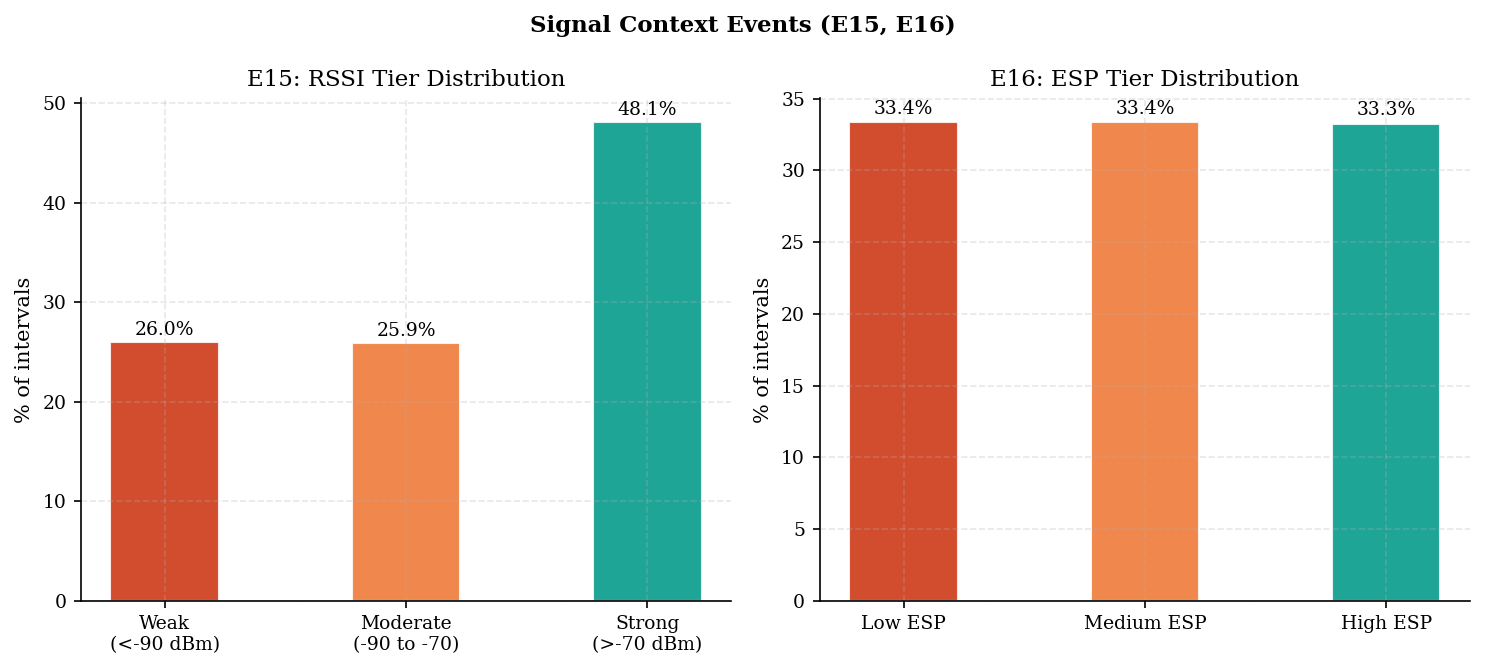

In [14]:
# Fig 02-F — Signal Context Events (E15, E16)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

rt     = ['weak','moderate','strong']
rt_labs = ['Weak\n(<-90 dBm)','Moderate\n(-90 to -70)','Strong\n(>-70 dBm)']
rt_pcts = [df['e15_rssi_tier'].eq(t).mean()*100 for t in rt]
bars = axes[0].bar(rt_labs, rt_pcts,
                    color=[C['red'],C['orange'],C['green']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,rt_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of intervals')
axes[0].set_title('E15: RSSI Tier Distribution')

et     = ['low_esp','medium_esp','high_esp']
et_labs = ['Low ESP','Medium ESP','High ESP']
et_pcts = [df['e16_esp_tier'].eq(t).mean()*100 for t in et]
bars = axes[1].bar(et_labs, et_pcts,
                    color=[C['red'],C['orange'],C['green']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,et_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('% of intervals')
axes[1].set_title('E16: ESP Tier Distribution')

fig.suptitle('Signal Context Events (E15, E16)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_f_signal_context_distribution')


## 7 · Burst Loss Event  *(§6.7)*

Classifies each interval by the number of consecutive packets lost before the received packet.  
Burst loss is qualitatively different from isolated loss — it creates contiguous data gaps  
that cannot be recovered by interpolation.

**B=3 threshold:** 3 consecutive losses = 3-minute gap at 60s TX interval — the minimum  
gap that visibly disrupts slowly-varying environmental signals (CO₂, temperature).

| Class | Condition | Interpretation |
|-------|-----------|---------------|
| no_loss | 0 | Clean reception |
| isolated | 1 | Single random collision |
| small_burst | 2–4 | Brief channel degradation |
| large_burst | ≥5 | Sustained interference episode |


In [15]:
# E17: burst loss classification
df['e17_loss_type'] = pd.cut(
    df['mac_to_radio_loss'],
    bins=[-1, 0, 1, 4, 10_000_000],
    labels=['no_loss', 'isolated', 'small_burst', 'large_burst']
)

print('Loss type distribution (E17):')
print(df['e17_loss_type'].value_counts(normalize=True).mul(100).round(2).astype(str).add('%').to_string())


KeyError: 'mac_to_radio_loss'

  Saved: figures/02_g_burst_loss_distribution


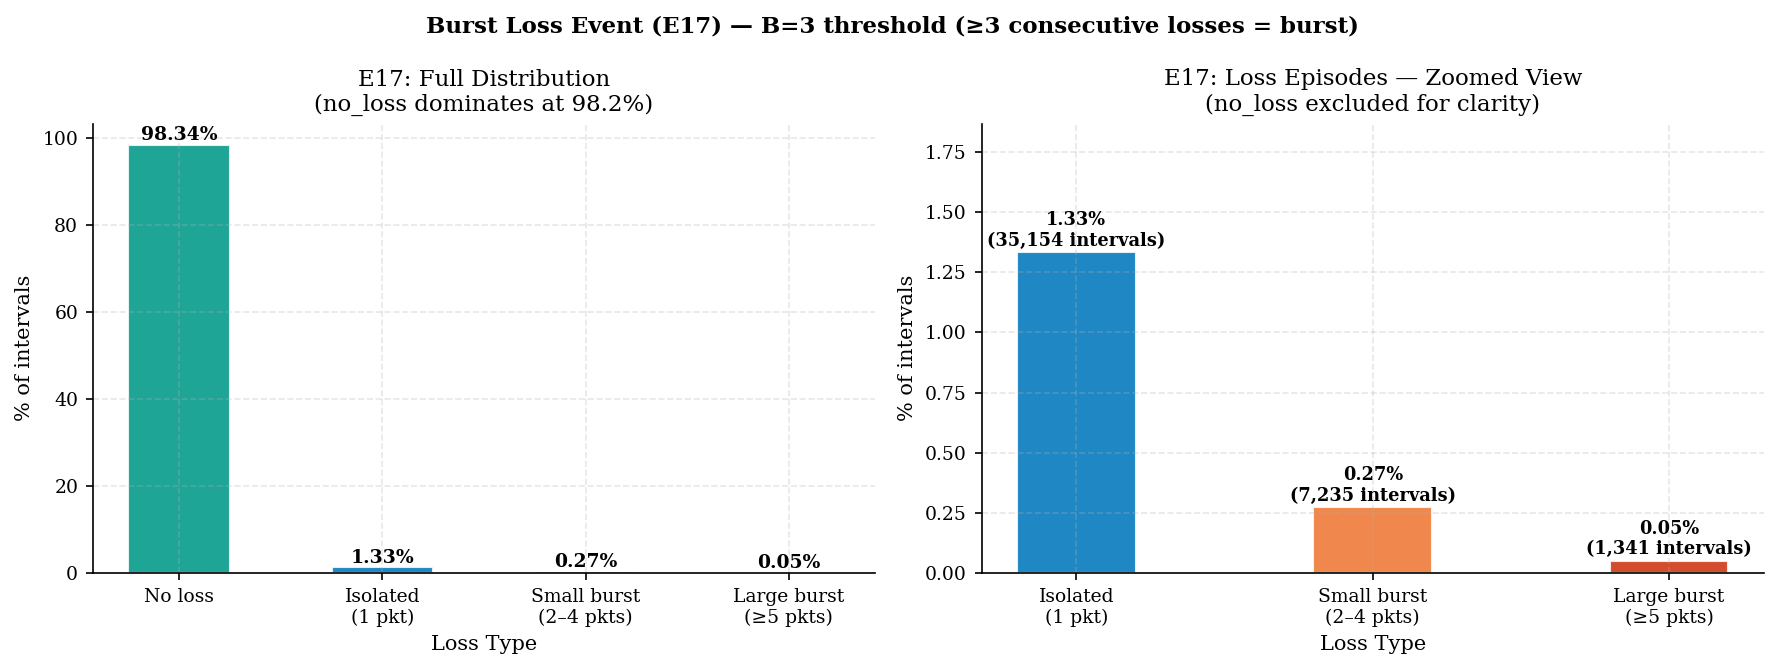

In [34]:
# Fig 02-G — Burst Loss Distribution (E17)
order    = ['no_loss','isolated','small_burst','large_burst']
olabs    = ['No loss','Isolated\n(1 pkt)','Small burst\n(2–4 pkts)','Large burst\n(≥5 pkts)']
o_pcts   = [df['e17_loss_type'].eq(o).mean()*100 for o in order]
o_counts = [df['e17_loss_type'].eq(o).sum() for o in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(olabs, o_pcts,
                    color=[C['green'],C['blue'],C['orange'],C['red']],
                    width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, o_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.1,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('% of intervals')
axes[0].set_xlabel('Loss Type')
axes[0].set_title('E17: Full Distribution\n(no_loss dominates at 98.2%)')

zoom_order  = ['isolated','small_burst','large_burst']
zoom_labs   = ['Isolated\n(1 pkt)','Small burst\n(2–4 pkts)','Large burst\n(≥5 pkts)']
zoom_pcts   = [df['e17_loss_type'].eq(o).mean()*100 for o in zoom_order]
zoom_counts = [df['e17_loss_type'].eq(o).sum() for o in zoom_order]

bars2 = axes[1].bar(zoom_labs, zoom_pcts,
                     color=[C['blue'],C['orange'],C['red']],
                     width=0.4, alpha=0.88, edgecolor='white')
for bar, v, cnt in zip(bars2, zoom_pcts, zoom_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.2f}%\n({cnt:,} intervals)',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_ylabel('% of intervals')
axes[1].set_xlabel('Loss Type')
axes[1].set_title('E17: Loss Episodes — Zoomed View\n(no_loss excluded for clarity)')
axes[1].set_ylim(0, max(zoom_pcts)*1.4)

fig.suptitle('Burst Loss Event (E17) — B=3 threshold (≥3 consecutive losses = burst)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_g_burst_loss_distribution')


## 8 · Event Taxonomy  *(Table 6.1)*

Complete list of all 17 events — copy to Table 6.1 in the thesis.


In [35]:
# Event Taxonomy Table — Table 6.1
event_taxonomy = [
    ('E1',  'Occupancy',      'e1_co2_tier',      'CO2 concentration tier (background/moderate/high)'),
    ('E2',  'Occupancy',      'e2_co2_rising',     'CO2 rising > 20ppm/60s — occupancy surge'),
    ('E3',  'Temporal',       'e3_is_weekday',     'Weekday vs weekend'),
    ('E4',  'Temporal',       'e4_time_of_day',    'Time-of-day band (night/morning/peak/evening)'),
    ('E5',  'Temporal',       'e5_office_hours',   'Office hours — weekday AND 08:00–17:59'),
    ('E6',  'Temporal',       'e6_season',         'Season (autumn/winter/spring/summer) — full year'),
    ('E7',  'Air Quality',    'e7_pm25_spike',     'PM2.5 device-specific 90th percentile spike'),
    ('E8',  'Air Quality',    'e8_pm25_tier',      'PM2.5 absolute tier (clean/moderate/elevated)'),
    ('E9',  'Atmospheric',    'e9_pressure_tier',  'Barometric pressure quartile tier'),
    ('E10', 'Atmospheric',    'e10_pressure_drop', 'Pressure drop event'),
    ('E11', 'Atmospheric',    'e11_humidity_tier', 'Relative humidity tier'),
    ('E12', 'Atmospheric',    'e12_temp_tier',     'Temperature quartile tier'),
    ('E13', 'TX Config',      'e13_sf',            'Individual SF value (7/8/9/10/11/12)'),
    ('E14', 'TX Config',      'e14_toa_class',     'ToA class: short_toa (SF7-10) vs long_toa (SF11-12)'),
    ('E15', 'Signal Context', 'e15_rssi_tier',     'RSSI tier (weak/moderate/strong)'),
    ('E16', 'Signal Context', 'e16_esp_tier',      'ESP tier (low/medium/high)'),
    ('E17', 'Burst Loss',     'e17_loss_type',     'Loss type: no_loss/isolated/small_burst/large_burst'),
]

print(f"{'ID':<5} {'Family':<15} {'Column':<22} {'Definition'}")
print('-'*80)
for row in event_taxonomy:
    print(f'{row[0]:<5} {row[1]:<15} {row[2]:<22} {row[3]}')
print(f'\nTotal: {len(event_taxonomy)} events across 7 families')


ID    Family          Column                 Definition
--------------------------------------------------------------------------------
E1    Occupancy       e1_co2_tier            CO2 concentration tier (background/moderate/high)
E2    Occupancy       e2_co2_rising          CO2 rising > 20ppm/60s — occupancy surge
E3    Temporal        e3_is_weekday          Weekday vs weekend
E4    Temporal        e4_time_of_day         Time-of-day band (night/morning/peak/evening)
E5    Temporal        e5_office_hours        Office hours — weekday AND 08:00–17:59
E6    Temporal        e6_season              Season (autumn/winter/spring/summer) — full year
E7    Air Quality     e7_pm25_spike          PM2.5 device-specific 90th percentile spike
E8    Air Quality     e8_pm25_tier           PM2.5 absolute tier (clean/moderate/elevated)
E9    Atmospheric     e9_pressure_tier       Barometric pressure quartile tier
E10   Atmospheric     e10_pressure_drop      Pressure drop event
E11   Atmospheric     e11

## 9 · Save  *(2_events.csv)*

Original columns retained. Event columns appended in family order.

| Group | Columns                                                                       |
|-------|-------------------------------------------------------------------------------|
| Original | all columns from `1_reconstructed.csv`                                        |
| Occupancy | `e1_co2_tier`, `e2_co2_rising`                                                |
| Temporal | `e3_is_weekday`, `e4_time_of_day`, `e5_office_hours`, `e6_season`             |
| Air Quality | `e7_pm25_spike`, `e8_pm25_tier`                                               |
| Atmospheric | `e9_pressure_tier`, `e10_pressure_drop`, `e11_humidity_tier`, `e12_temp_tier` |
| TX Config | `e13_sf`, `e14_toa_class`, `e14_toa_ms`                                       |
| Signal Context | `e15_rssi_tier`, `e16_esp_tier`                                               |
| Burst Loss | `e17_loss_type`                                                               |

In [36]:
original_cols = [c for c in df.columns
                 if not (c.startswith('e') and '_' in c)
                 and c not in ['hour', 'dayofweek', 'month', 'exp_pl']]

event_cols_ordered = [
    'e1_co2_tier',  'e2_co2_rising',
    'e3_is_weekday', 'e4_time_of_day', 'e5_office_hours', 'e6_season',
    'e7_pm25_spike', 'e8_pm25_tier',
    'e9_pressure_tier', 'e10_pressure_drop', 'e11_humidity_tier', 'e12_temp_tier',
    'e13_sf', 'e14_toa_class', 'e14_toa_ms',
    'e15_rssi_tier', 'e16_esp_tier',
    'e17_loss_type',
]

df = df[[c for c in original_cols if c in df.columns] +
        [c for c in event_cols_ordered if c in df.columns]]
df.to_csv(DATA_DIR / '2_events.csv', index=False)

print(f'Saved  : {DATA_DIR / "2_events.csv"}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {len(df.columns)} total | 17 events')
print(f'Event columns: {[c for c in df.columns if c.startswith("e") and "_" in c]}')


Saved  : ..\data\2_events.csv
Rows   : 2,634,930
Columns: 43 total | 17 events
Event columns: ['e1_co2_tier', 'e2_co2_rising', 'e3_is_weekday', 'e4_time_of_day', 'e5_office_hours', 'e6_season', 'e7_pm25_spike', 'e8_pm25_tier', 'e9_pressure_tier', 'e10_pressure_drop', 'e11_humidity_tier', 'e12_temp_tier', 'e13_sf', 'e14_toa_class', 'e14_toa_ms', 'e15_rssi_tier', 'e16_esp_tier', 'e17_loss_type']
